In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import *
from sklearn.ensemble import RandomForestClassifier

from scipy.stats import ttest_ind

In [2]:
df = pd.read_csv(r"C:\Users\Iram\Desktop\Bank_Marketing_Analysis\DATA\bank-full.csv.csv")

In [3]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [7]:
df.duplicated().sum()

0

In [8]:
df.shape

(45211, 17)

In [9]:
# Data Cleaning and Preprocessing:
# - Handle missing values: Identify and appropriately handle missing values in the dataset.


In [10]:
df.isnull().sum() 

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [11]:
# - Standardize columns: Ensure all categorical data is standardized (e.g., consistent capitalization, removing leading/trailing spaces).


In [12]:
for col in df.select_dtypes(include = "object").columns:
    df[col] = df[col].str.strip()

In [13]:
for col in df.select_dtypes(include = "object").columns:
    df[col] = df[col].str.lower()

In [14]:
# - Perform encoding for y column(categorical)

In [15]:
le = LabelEncoder()

df["y"] = le.fit_transform(df["y"])


In [16]:
df["y"].head()

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int32

In [17]:
# Exploratory Data Analysis (EDA):
#  Demographic Analysis: Analyze the age distribution and identify trends based on job, marital status, and education.


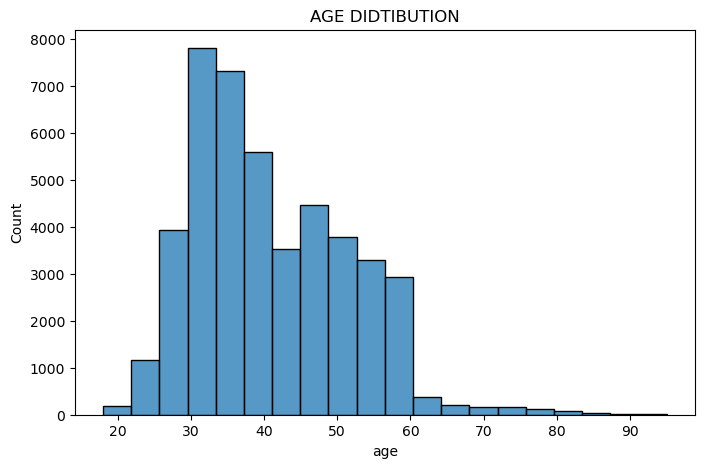

In [18]:
# AGE DISTIBUTION

plt.figure(figsize = (8,5))
sns.histplot(df["age"],bins = 20)
plt.title("AGE DIDTIBUTION")
plt.show()

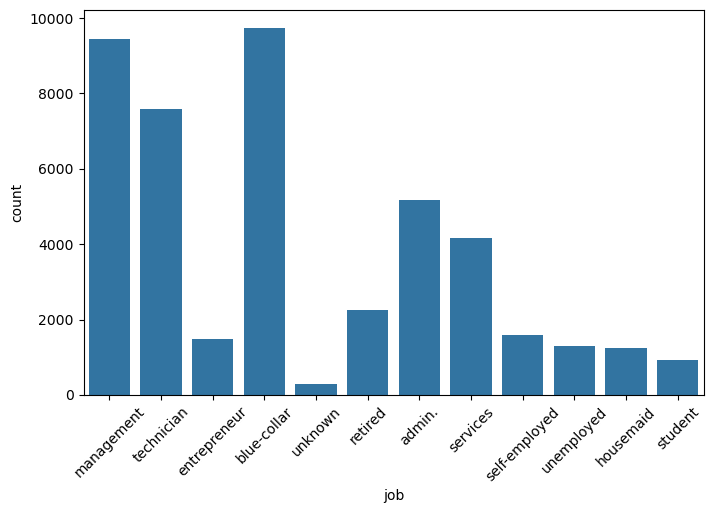

In [19]:
# JOB ANALYSIS

plt.figure(figsize = (8,5))
sns.countplot(x = "job",data = df)
plt.xticks(rotation = 45)
plt.show()

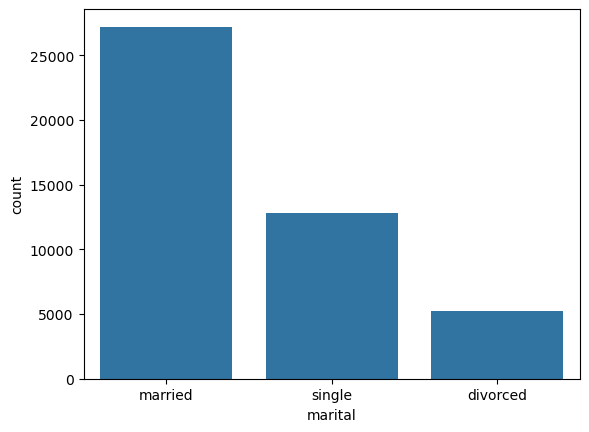

In [20]:
# MARITAL STSTUS

sns.countplot(x = "marital",data = df)
plt.show()

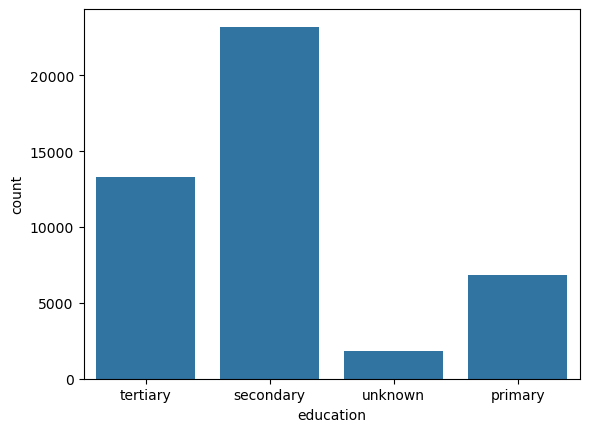

In [21]:
# EDUCATION

sns.countplot(x = "education",data = df)
plt.show()

In [22]:
# Loan Analysis: Investigate the relationship between housing loan and personal loan status.


In [23]:
pd.crosstab(df["housing"],df["loan"])

loan,no,yes
housing,,
no,17204,2877
yes,20763,4367


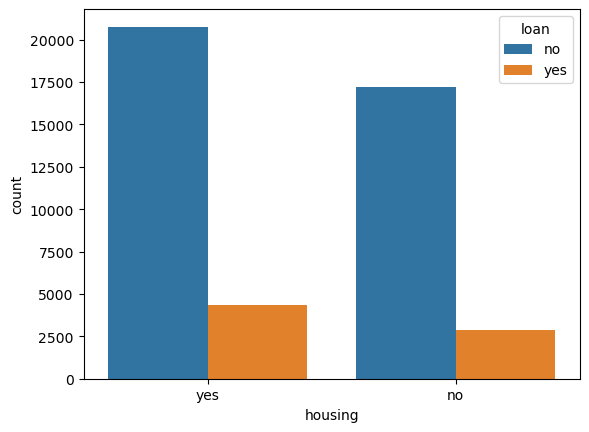

In [24]:
sns.countplot(x='housing', hue='loan', data=df)

plt.show()

In [25]:
# Campaign Analysis: Examine the distribution of campaign contacts and their success rate

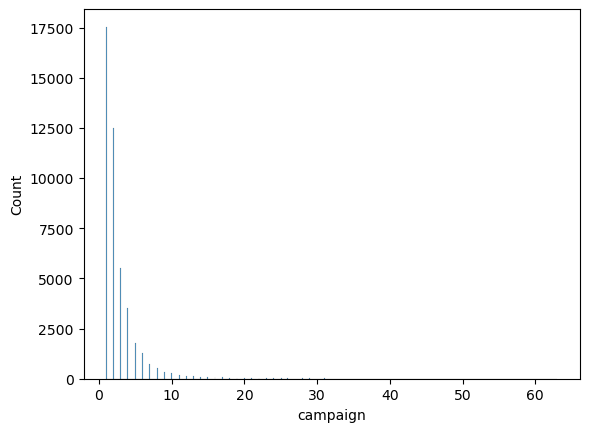

In [26]:


sns.histplot(df['campaign'])

plt.show()

In [27]:
pd.crosstab(df['campaign'], df['y'])

y,0,1
campaign,,
1,14983,2561
2,11104,1401
3,4903,618
4,3205,317
5,1625,139
6,1199,92
7,688,47
8,508,32
9,306,21


In [28]:
# 3. Statistical Analysis:
#  Hypothesis Testing: Conduct hypothesis testing to determine if there is a significant difference in balance between clients with and without a housing loan.


In [29]:
loan = df[df['housing']=='yes']['balance']

no_loan = df[df['housing']=='no']['balance']

In [30]:
t,p = ttest_ind(loan,no_loan)

print("T-value =",t)

print("P-value =",p)

T-value = -14.656496906456644
P-value = 1.5826321844954334e-48


In [31]:
if p < 0.05 :
    print("null hypothesis is accepted")
else:
    print("null hypothesis is rejected")

null hypothesis is accepted


In [32]:
# Correlation Analysis: Analyze the correlation between campaign-related variables (e.g., duration, number of contacts) and the success rate of term deposit subscriptions.

In [33]:
corr = df[['duration','campaign','previous','pdays','y']].corr()

corr

,duration,campaign,previous,pdays,y
duration,1.000000,-0.084570,0.001203,-0.001565,0.394521
campaign,-0.084570,1.000000,-0.032855,-0.088628,-0.073172
previous,0.001203,-0.032855,1.000000,0.454820,0.093236
pdays,-0.001565,-0.088628,0.454820,1.000000,0.103621
y,0.394521,-0.073172,0.093236,0.103621,1.000000


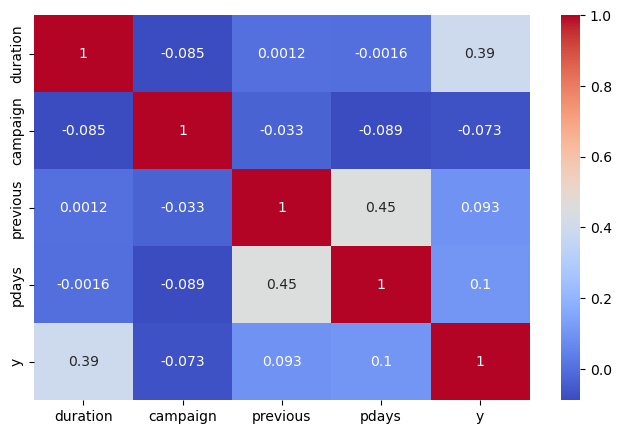

In [34]:
plt.figure(figsize=(8,5))

sns.heatmap(corr,annot=True,cmap='coolwarm')

plt.show()

In [35]:
# 4. Machine Learning:
# Predictive Modeling: Build a classification model to predict whether a client will subscribe to a term deposit based on the provided features.
# Evaluate the model using appropriate metrics (e.g., accuracy, precision, recall)

In [36]:
# SEPERATE FEATURE

X = df.drop('y',axis=1)

y = df['y']

In [37]:
# Encode Remaining Categorical Columns

X = pd.get_dummies(X,drop_first=True)

In [38]:
# Train Test Split

X_train,X_test,y_train,y_test=train_test_split(
X,y,
test_size=0.2,
random_state=42)

In [39]:
# Build Model

model = RandomForestClassifier()

model.fit(X_train,y_train)

RandomForestClassifier()

In [40]:
# Prediction

pred=model.predict(X_test)

In [41]:
# Evaluation

print("Accuracy =",accuracy_score(y_test,pred))

print("Precision =",precision_score(y_test,pred))

print("Recall =",recall_score(y_test,pred))

print(confusion_matrix(y_test,pred))

print(classification_report(y_test,pred))

Accuracy = 0.9046776512219397
Precision = 0.6748091603053435
Recall = 0.40513290559120074
[[7739  213]
 [ 649  442]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.67      0.41      0.51      1091

    accuracy                           0.90      9043
   macro avg       0.80      0.69      0.73      9043
weighted avg       0.89      0.90      0.89      9043

